<a href="https://colab.research.google.com/github/fathanick/Fundamentals-of-Data-Science/blob/main/K-Means/K_Means_Clustering_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial K-Means Clustering: Segmentasi Pelanggan Mall

## Tujuan
Melakukan segmentasi pelanggan mall menggunakan **K-Means Clustering** berdasarkan:
- **Annual Income (k$)**
- **Spending Score (1-100)**

**Dataset source:** [Mall_Customers.csv](https://gist.github.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf)


In [1]:
# 1. Import library dan load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

url = 'https://gist.github.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv'
data = pd.read_csv(url)

print('Dataset shape:', data.shape)
print(data.head())


Dataset shape: (200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


## Step 1: Pemilihan Fitur

Kita hanya memakai 2 fitur agar mudah divisualisasikan dan fokus pada pola belanja pelanggan.


In [5]:
# 2. Pilih fitur yang jalankan Elbow Method
features = data[['Annual Income (k$)', 'Spending Score (1-100)']]
print(features.describe())

       Annual Income (k$)  Spending Score (1-100)
count          200.000000              200.000000
mean            60.560000               50.200000
std             26.264721               25.823522
min             15.000000                1.000000
25%             41.500000               34.750000
50%             61.500000               50.000000
75%             78.000000               73.000000
max            137.000000               99.000000


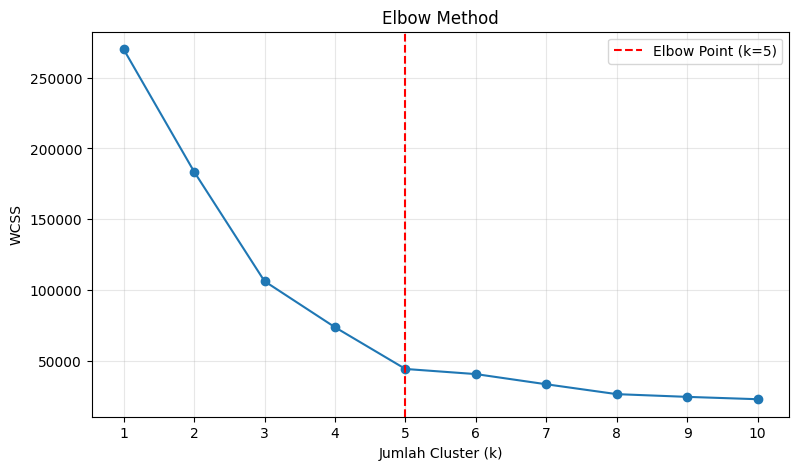

In [6]:
# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))
plt.axvline(x=5, color='red', linestyle='--', label='Elbow Point (k=5)')
plt.legend()
plt.show()


## Step 2: Implementasi K-Means

Berdasarkan Elbow Method, jumlah cluster optimal adalah **5**.


In [7]:
# 3. Jalankan K-Means dan visualisasi
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(features)
data['Cluster'] = labels

print('Distribusi cluster:')
print(data['Cluster'].value_counts().sort_index())

Distribusi cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


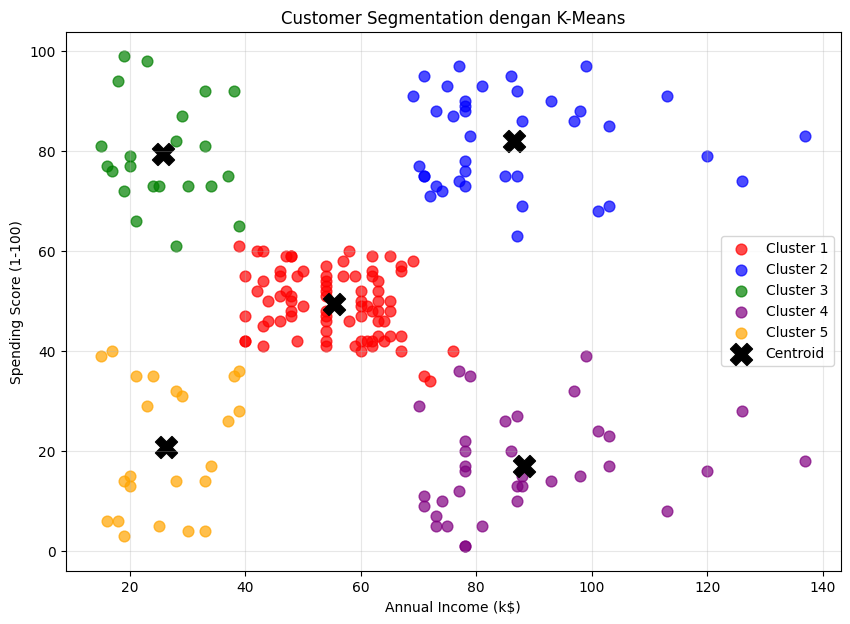

In [8]:
# Visualisasi
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(5):
    cluster_data = features[labels == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=60, alpha=0.7, c=colors[i], label=f'Cluster {i+1}')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=250, marker='X', label='Centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation dengan K-Means')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# 4. Analisis karakteristik setiap cluster
print("\n" + "="*80)
print("KARAKTERISTIK SETIAP CLUSTER")
print("="*80)

for cluster_id in range(5):
    cluster_data = data[data['Cluster'] == cluster_id]
    avg_income = cluster_data['Annual Income (k$)'].mean()
    avg_spending = cluster_data['Spending Score (1-100)'].mean()

    print(f"\nCLUSTER {cluster_id + 1} ({len(cluster_data)} pelanggan, {len(cluster_data)/len(data)*100:.1f}%)")
    print(f"  Rata-rata Income: ${avg_income:.2f}k  |  Rata-rata Spending Score: {avg_spending:.2f}")

    if avg_income > 80 and avg_spending > 50:
        segment = "💎 Premium (High Income, High Spending)"
    elif avg_income < 60 and avg_spending > 70:
        segment = "🛍️ Fashion-Conscious (Low Income, High Spending)"
    elif avg_income > 80 and avg_spending < 40:
        segment = "💰 Careful Spender (High Income, Low Spending)"
    elif avg_income < 60 and avg_spending < 40:
        segment = "📊 Budget-Conscious (Low Income, Low Spending)"
    else:
        segment = "⚖️ Middle Class (Medium Income, Medium Spending)"

    print(f"  Segmen: {segment}")



KARAKTERISTIK SETIAP CLUSTER

CLUSTER 1 (81 pelanggan, 40.5%)
  Rata-rata Income: $55.30k  |  Rata-rata Spending Score: 49.52
  Segmen: ⚖️ Middle Class (Medium Income, Medium Spending)

CLUSTER 2 (39 pelanggan, 19.5%)
  Rata-rata Income: $86.54k  |  Rata-rata Spending Score: 82.13
  Segmen: 💎 Premium (High Income, High Spending)

CLUSTER 3 (22 pelanggan, 11.0%)
  Rata-rata Income: $25.73k  |  Rata-rata Spending Score: 79.36
  Segmen: 🛍️ Fashion-Conscious (Low Income, High Spending)

CLUSTER 4 (35 pelanggan, 17.5%)
  Rata-rata Income: $88.20k  |  Rata-rata Spending Score: 17.11
  Segmen: 💰 Careful Spender (High Income, Low Spending)

CLUSTER 5 (23 pelanggan, 11.5%)
  Rata-rata Income: $26.30k  |  Rata-rata Spending Score: 20.91
  Segmen: 📊 Budget-Conscious (Low Income, Low Spending)


## Step 3: Interpretasi dan Aplikasi Bisnis

**5 Segmen Pelanggan:**

| Cluster | Segmen | Karakteristik | Strategi Marketing |
|---------|--------|---------------|-------------------|
| 1 | 💎 Premium | High Income, High Spending | Produk eksklusif, loyalty program |
| 2 | 🛍️ Fashion-Conscious | Low Income, High Spending | Tren fashion, cicilan, flash sales |
| 3 | 💰 Careful Spender | High Income, Low Spending | Value proposition, membership |
| 4 | 📊 Budget-Conscious | Low Income, Low Spending | Budget-friendly, promo hemat |
| 5 | ⚖️ Middle Class | Medium Income, Medium Spending | Mid-range products, balanced offers |

**Manfaat bisnis:**
- ✅ Personalisasi marketing per segmen
- ✅ Penentuan harga sesuai daya beli
- ✅ Strategi promosi yang lebih efektif
- ✅ Optimasi inventory berdasarkan preferensi segmen
